# Core Analysis Runner

Run MATLAB-equivalent analysis steps for MIMIC-only outputs:
1. Select best model from `recqvi`
2. Recover best model payload from `allpols`
3. Fig 2A safety curve
4. Fig 2B policy value boxplot
5. Fig 2C calibration curve
6. Fig 2D per-patient return histogram

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "analysis").exists() else cwd.parent
analysis_dir = repo_root / "analysis"

for p in (repo_root, analysis_dir):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from core_analysis import select_best_model, recover_best_model
from core_analysis_fig2 import (
    plot_fig2a_safety_curve,
    plot_fig2b_boxplot,
    build_calibration_data,
    plot_fig2c_calibration,
    plot_fig2d_histogram,
)

In [2]:
# Set your run tag here
run_tag = "20260210_084044"
out_dir = Path("analysis") / "figures" / f"mdp_core_{run_tag}"
out_dir.mkdir(parents=True, exist_ok=True)
out_dir

PosixPath('analysis/figures/mdp_core_20260210_084044')

In [3]:
best_info = select_best_model(run_tag)
best_info

{'bestpol': 240, 'best_value': 88.32108279931263, 'n_candidates': 500}

In [4]:
best_payload = recover_best_model(run_tag, bestpol=best_info["bestpol"])
best_payload["path"], best_payload["modl"]

('/home/hun/workspace/Q-Learning_Application/data/mdp_output/mdp_core_20260210_084044/allpols/model_0083.npz',
 240)

In [5]:
# Sanity checks
print("Qon shape:", best_payload["Qon"].shape)
print("physpol shape:", best_payload["physpol"].shape)
print("transitionr shape:", best_payload["transitionr"].shape)
print("transitionr2 shape:", best_payload["transitionr2"].shape)
print("R shape:", best_payload["R"].shape)
print("C shape:", best_payload["C"].shape)
print("train shape:", best_payload["train"].shape)
print("qldata3train shape:", best_payload["qldata3train"].shape)
print("qldata3test shape:", best_payload["qldata3test"].shape)

Qon shape: (752, 25)
physpol shape: (752, 25)
transitionr shape: (752, 752, 25)
transitionr2 shape: (752, 752, 25)
R shape: (752, 25)
C shape: (750, 47)
train shape: (278332,)
qldata3train shape: (237872, 8)
qldata3test shape: (61400, 8)


(<Figure size 600x600 with 1 Axes>, <Figure size 700x600 with 1 Axes>)

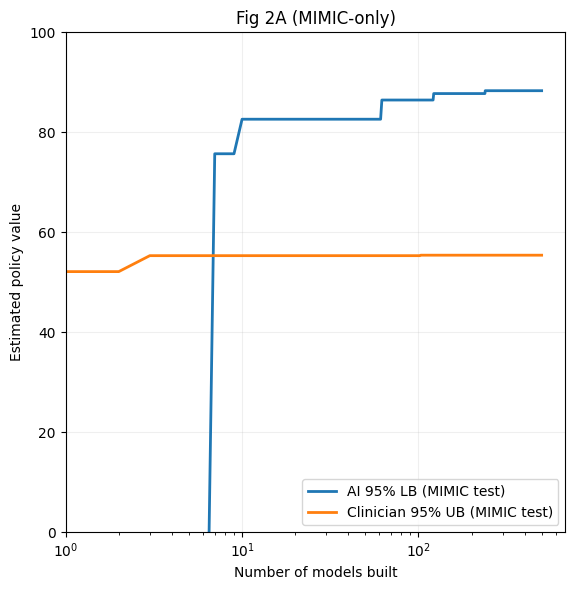

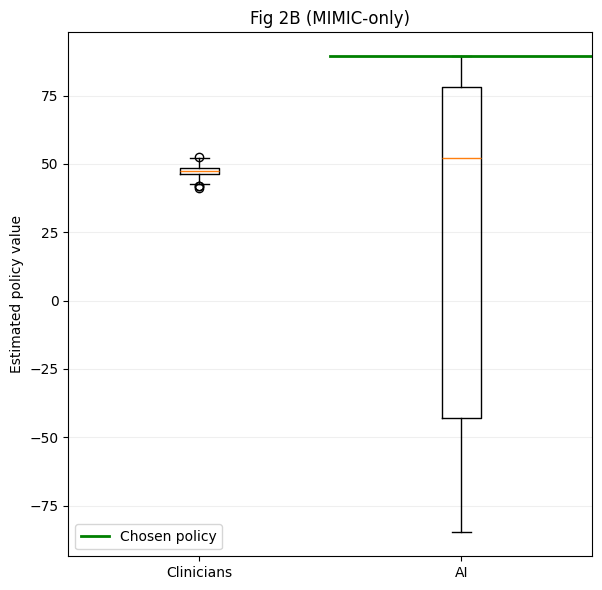

In [6]:
fig2a = plot_fig2a_safety_curve(run_tag, save_path=out_dir / "fig2a_safety.png")
fig2b = plot_fig2b_boxplot(run_tag, save_path=out_dir / "fig2b_boxplot.png")
fig2a, fig2b

In [7]:
cal = build_calibration_data(run_tag, bestpol=best_info["bestpol"], num_iter=100)
cal.bootql.shape, cal.prog.shape

((100,), (6624691, 4))

(<Figure size 700x600 with 1 Axes>, <Figure size 700x600 with 1 Axes>)

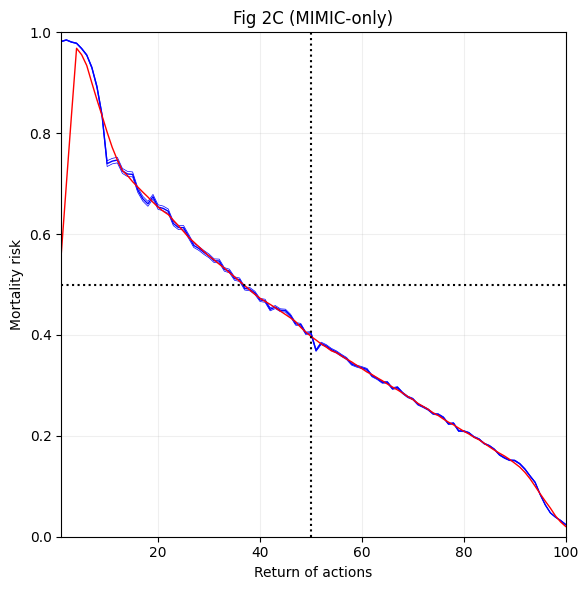

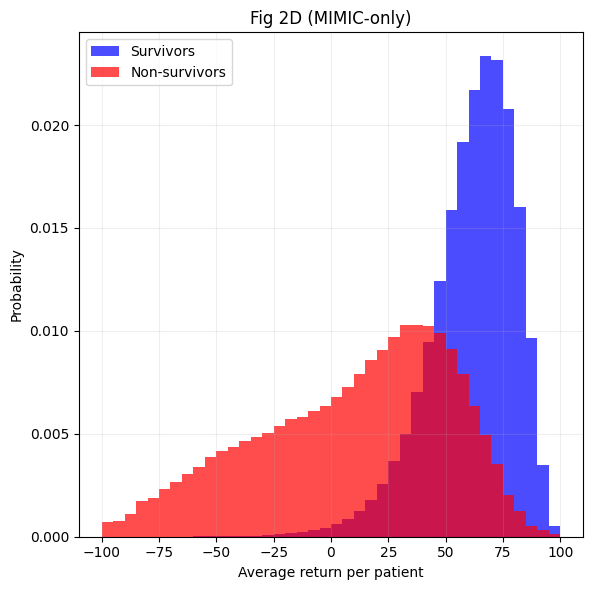

In [9]:
fig2c = plot_fig2c_calibration(cal, save_path=out_dir / "fig2c_calibration.png")
fig2d = plot_fig2d_histogram(cal, save_path=out_dir / "fig2d_hist.png")
fig2c, fig2d

In [10]:
sorted(str(p) for p in out_dir.glob("*.png"))

['analysis/figures/mdp_core_20260210_084044/fig2a_safety.png',
 'analysis/figures/mdp_core_20260210_084044/fig2b_boxplot.png',
 'analysis/figures/mdp_core_20260210_084044/fig2c_calibration.png',
 'analysis/figures/mdp_core_20260210_084044/fig2d_hist.png']